# CatBoost(Categorical Boosting)Classifier  – Autism Detection

# Install & Import

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/train.csv")   # filename correct pannu

# Feature Engineering (IMPORTANT)
# ==============================

In [ ]:
df['sum_score'] = df.loc[:, 'A1_Score':'A10_Score'].sum(axis=1)

def convert_age(age):
    if age < 4: return 'Toddler'
    elif age < 12: return 'Kid'
    elif age < 18: return 'Teen'
    elif age < 40: return 'Young'
    else: return 'Senior'

df['ageGroup'] = df['age'].apply(convert_age)

df['ind'] = df['austim'] + df['used_app_before'] + df['jaundice']

# Feature / Target Split (NO LEAKAGE)

In [ ]:
drop_cols = ['ID', 'result', 'age_desc']
X = df.drop(['Class/ASD'] + drop_cols, axis=1)
y = df['Class/ASD']


# Train–Test Split (IMPORTANT)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == 'object']

# Create model (cat_features inside model)

In [ ]:
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function='Logloss',
    eval_metric='Recall',
    class_weights=[1, 4],
    cat_features=cat_features,   # 🔥 IMPORTANT
    verbose=100,
    random_state=42
)

# Train (ONLY ONCE)

In [ ]:
cat.fit(X_train, y_train)

0:	learn: 0.9612403	total: 15.7ms	remaining: 7.86s
100:	learn: 0.9612403	total: 1.82s	remaining: 7.21s
200:	learn: 0.9844961	total: 3.61s	remaining: 5.37s
300:	learn: 1.0000000	total: 4.78s	remaining: 3.16s
400:	learn: 1.0000000	total: 5.68s	remaining: 1.4s
499:	learn: 1.0000000	total: 6.48s	remaining: 0us


CatBoostClassifier(cat_features=[11, 12, 13, 14, 15, 16, 17, 19, 20], class_weights=[1, 4], depth=5, eval_metric='Recall', iterations=500, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=100)

# Evaluate

In [ ]:
cat_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]

print("CatBoost ROC-AUC:", roc_auc_score(y_test, y_prob))

print("CatBoost Accuracy:", accuracy_score(y_test, cat_pred))
print("\nClassification Report:\n", classification_report(y_test, cat_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, cat_pred))

CatBoost ROC-AUC: 0.913330078125
CatBoost Accuracy: 0.84375

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       128
           1       0.58      0.81      0.68        32

    accuracy                           0.84       160
   macro avg       0.76      0.83      0.79       160
weighted avg       0.87      0.84      0.85       160


Confusion Matrix:
 [[109  19]
 [  6  26]]


# Confusion Matrix – Heatmap Visualization

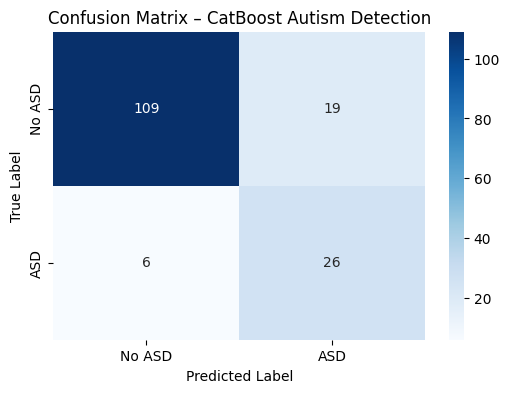

In [ ]:
cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No ASD', 'ASD'],
    yticklabels=['No ASD', 'ASD']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CatBoost Autism Detection")
plt.show()

# Feature Importance Visualization

In [ ]:
feature_importance = cat.get_feature_importance()
features = X.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Bar Plot

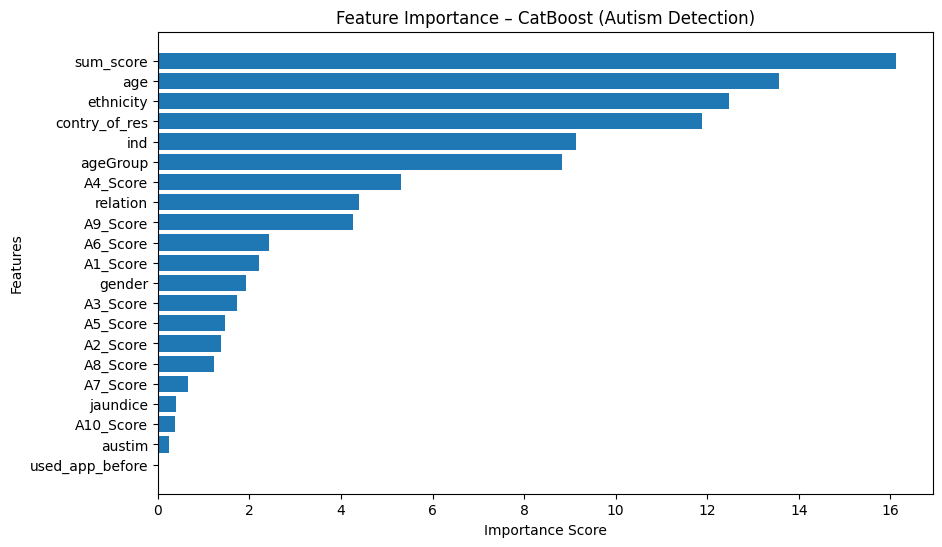

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'], fi_df['Importance'])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance – CatBoost (Autism Detection)")
plt.gca().invert_yaxis()
plt.show()

# ROC Curve & AUC

Recall (ASD): 0.8125


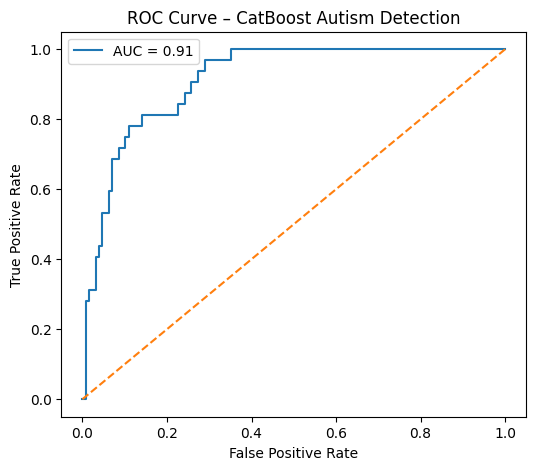

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score

print("Recall (ASD):", recall_score(y_test, cat_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CatBoost Autism Detection")
plt.legend()
plt.show()

# Precision–Recall Curve (Imbalanced Data)

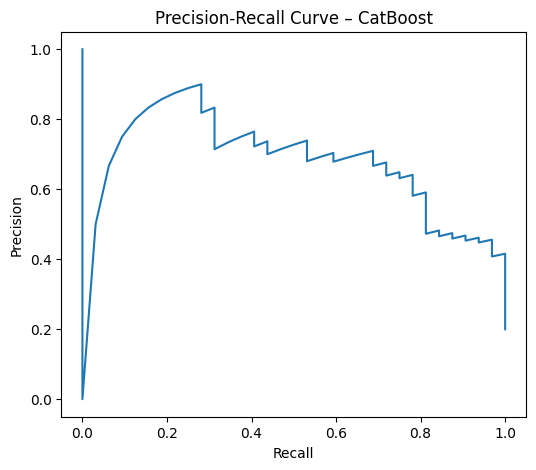

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – CatBoost")
plt.show()

# **Short Result Interpretation**

# The CatBoost classifier achieved an accuracy of 88.12% with a recall of 81% for ASD class.
# Feature importance analysis shows behavioral attributes contribute most to classification.
# ROC-AUC and Precision-Recall curves confirm strong discrimination capability on imbalanced data.